# E79 · The cosmic microwave background at the level of the map

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) two 16 x 16 degree patches of the **Planck 2018 SMICA** map of the cosmic microwave background (ESA Planck Legacy Archive, via IRSA): the full-mission temperature map, the two **half-mission** maps (for the noise), the **common confidence mask**, and SMICA's own inpainted map; one patch surrounds the **Large Magellanic Cloud**, the other lies at high northern latitude; (2) the **Planck 2018 best-fit ΛCDM** temperature power spectrum and Planck's binned full-sky spectrum |
| **You will learn** | The CMB as a **Gaussian random field** on a flat patch: Fourier (Hartley) modes, the power spectrum, what a summary statistic keeps and throws away, and when it is **sufficient** · why the obvious power-spectrum estimate from a **masked** map is biased (mode coupling, noise bias, the beam) · **field-level inference**: every pixel of the sky as a parameter, sampled jointly with the power spectrum · checking a sampler against an **exact** answer · the famous **centred vs non-centred** problem, both ways round (high vs low signal-to-noise), and **partial non-centring** · why HMC with a diagonal mass matrix fails on a masked map (**conditioning**) · the **Wandelt-Eriksen Gibbs sampler**: constrained realisations by **preconditioned conjugate gradients**, an inverse-gamma step, and a **rescaling move** · flat-sky traps: non-periodic edges, **aliasing**, projection stretch · posterior products: the **Wiener-filtered** map, **constrained realisations** of the sky *behind* the LMC, a per-pixel sd map, an animation, bandpower posteriors · **coverage** on simulated skies · from bandpowers to a two-parameter model in PyMC, and a systematic that looks like physics |

## The setting

The cosmic microwave background (CMB) is light released 380,000 years after the Big Bang, when
the universe first became transparent. Its temperature is 2.7255 K in every direction to one part
in a thousand; the part in 100,000 that varies from place to place is a snapshot of the density
ripples that later grew into galaxies. ESA's Planck satellite (2009-2013) mapped those ripples over
the whole sky, and most of what we know about the age, contents and geometry of the universe comes
from them.

The standard route from the map to cosmology goes through a **summary statistic**: the angular
power spectrum $C_\ell$, the variance of the map at angular scale $180°/\ell$. E08 did the same
kind of thing with supernovae - distances first, cosmology second. Here we ask what it takes to
work with **the map itself**: every pixel of the sky is a parameter, and the power spectrum is
inferred *jointly* with the sky it describes. That is called **field-level inference**. It sounds
extravagant (tens of thousands of parameters for one patch), but it is the natural Bayesian answer
to three real problems:

* parts of the sky are **masked** (our own Galaxy, nearby galaxies, bright radio sources), and a
  hole in the map mixes the scales we want to measure;
* the **noise** differs from place to place (Planck scanned some parts of the sky much more often);
* and the model then fills the holes with **every sky consistent with the data**, which is the
  honest way to show what is behind a mask.

Our main patch contains the **Large Magellanic Cloud (LMC)**, a neighbour galaxy whose dust and
gas outshine the CMB; the Planck mask cuts a hole about four degrees across. What does the CMB look
like behind it? And does the part of the patch we *can* see agree with the Planck spectrum?

| part | question | tool |
|---|---|---|
| A | What do the data look like? | the SMICA map, the confidence mask, noise from half-mission differences |
| B | What kind of object is the CMB? | Gaussian random fields on a flat patch, Hartley modes, the power spectrum, phases |
| C | Why not just measure the power spectrum? | a naive estimate from the masked map, and simulations that show its bias |
| D | A field-level model in PyMC | a simulated patch with an exact answer; centred vs non-centred at high and low S/N; what a mask does to HMC |
| E | The real sky | the Gibbs sampler: preconditioned conjugate gradients, an inverse-gamma step, a rescaling move |
| F | What is behind the LMC? | the posterior-mean map, posterior skies, an sd map, an animation, bandpowers |
| G | Can we trust it? | simulated skies with a known, non-Planck truth: coverage |
| H | From bandpowers to parameters | an amplitude-and-tilt model in PyMC, and a systematic that looks like a tilt |

Everything here uses NumPy, SciPy and PyMC - no astronomy packages in the notebook (healpy was
used once, in `tools/build_e79_cmb.py`, to cut the patches out of the HEALPix maps). Where the
professional analyses do more (full-sky spherical harmonics, foreground models, polarisation,
lensing), the notebook says so.

In [1]:
import io
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import scipy.fft as sf
import xarray as xr
from IPython.display import HTML, Image, display
from matplotlib import animation
from matplotlib.colors import LogNorm
from scipy import ndimage

from pymc_challenges import data

RANDOM_SEED = 79
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", category=UserWarning, module="arviz")
warnings.filterwarnings("ignore", message="Only .* samples per chain")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
T_START = time.time()


def show_jpeg(fig, quality=85):
    """Maps compress badly as PNG: show them as JPEG (a fraction of the size)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=90, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. The data

Planck observed the sky in nine frequency bands. The CMB has the same temperature spectrum in all
of them; our Galaxy, other galaxies and radio sources do not. **SMICA** is one of four Planck
methods that combine the bands, scale by scale, into a single map of the CMB with foregrounds
removed as well as possible. Where the removal is not trustworthy, a **confidence mask** says so; we
use Planck's recommended **common mask**, which keeps 77.9% of the sky.

The build script cut two 16 x 16 degree patches out of the full-resolution maps (HEALPix, 1.7
arcminute pixels) with a gnomonic (tangent-plane) projection. We work at **7.5 arcminute pixels**,
128 x 128 of them, and call a pixel usable only if all of its sub-samples are inside the mask.
Planck also released each map made from the first and the second half of the mission. The CMB is
the same in both halves and the noise is not, so **half the difference of the two half-mission maps
is a map of pure noise** with the same statistics as the noise of the full map - the standard way
to measure it.

In [2]:
data.describe("planck_smica_patches")
P = np.load(data.path("planck_smica_patches"))
data.describe("planck_tt_theory")
theory = data.load("planck_tt_theory")
binned = data.load("planck_tt_binned")

N_OBS, NSUB = 128, 8                     # 128 x 128 model pixels, each the mean of 8 x 8 point samples
ARCMIN = np.pi / 180 / 60
RESO = 7.5 * ARCMIN
PATCH_DEG = N_OBS * 7.5 / 60


def block(a, f=2):
    """3.75' -> 7.5' pixels by 2 x 2 averaging."""
    n = a.shape[0] // f
    return a.reshape(n, f, n, f).mean(axis=(1, 3))


def patch(key):
    y = block(P[f"{key}_I"]).astype(float)
    observed = block(P[f"{key}_mask"]) == 1          # every sub-sample inside the common mask
    noise = block((P[f"{key}_hm1"] - P[f"{key}_hm2"]) / 2).astype(float)
    # local noise level: smoothed variance of the half-difference map over usable pixels (1 degree)
    num = ndimage.gaussian_filter(np.where(observed, noise**2, 0.0), 8)
    den = ndimage.gaussian_filter(observed.astype(float), 8)
    sigma = np.sqrt(num / np.maximum(den, 1e-3))
    return y, observed, noise, sigma


y_lmc, obs_lmc, noise_lmc, sigma_lmc = patch("lmc")
y_nth, obs_nth, noise_nth, sigma_nth = patch("north")
inp_lmc = block(P["lmc_inp"]).astype(float)
for name, y, obs, sig in [("LMC", y_lmc, obs_lmc, sigma_lmc), ("north", y_nth, obs_nth, sigma_nth)]:
    print(f"{name:5s}: {1 - obs.mean():.1%} of pixels masked; map sd {y[obs].std():.0f} uK; "
          f"noise sd per 7.5' pixel {sig[obs].min():.1f}-{sig[obs].max():.1f} uK")

planck_smica_patches: NumPy .npz (open data.path(...) with np.load): two 16 x 16 degree gnomonic patches, 256 x 256 pixels of 3.75 arcmin, each pixel the mean of 4 x 4 point samples of the Nside-2048 maps; rows run up in galactic latitude, columns towards decreasing galactic longitude. Per patch (prefix 'lmc_' centred on (l, b) = (280, -35), around the Large Magellanic Cloud; 'north_' on (60, 55)): I (full-mission temperature, uK_CMB), hm1, hm2 (half-mission maps), inp (SMICA's inpainted map, released 'for PR purposes'), mask (fraction of samples kept by the common mask; 1 = usable), tmask (the same for SMICA's own confidence mask), centre. Global: reso_arcmin, n, sub, beam_fwhm_arcmin (5: SMICA's effective Gaussian beam), pixwin_2048 (HEALPix Nside-2048 temperature pixel window, ell = 0..4096, from healpy).
  source: Planck 2018 (PR3) SMICA CMB temperature maps (COM_CMB_IQU-smica_2048_R3.00_full, _hm1, _hm2; Planck Collaboration 2020, A&A 641, A4) and the common intensity confidence m

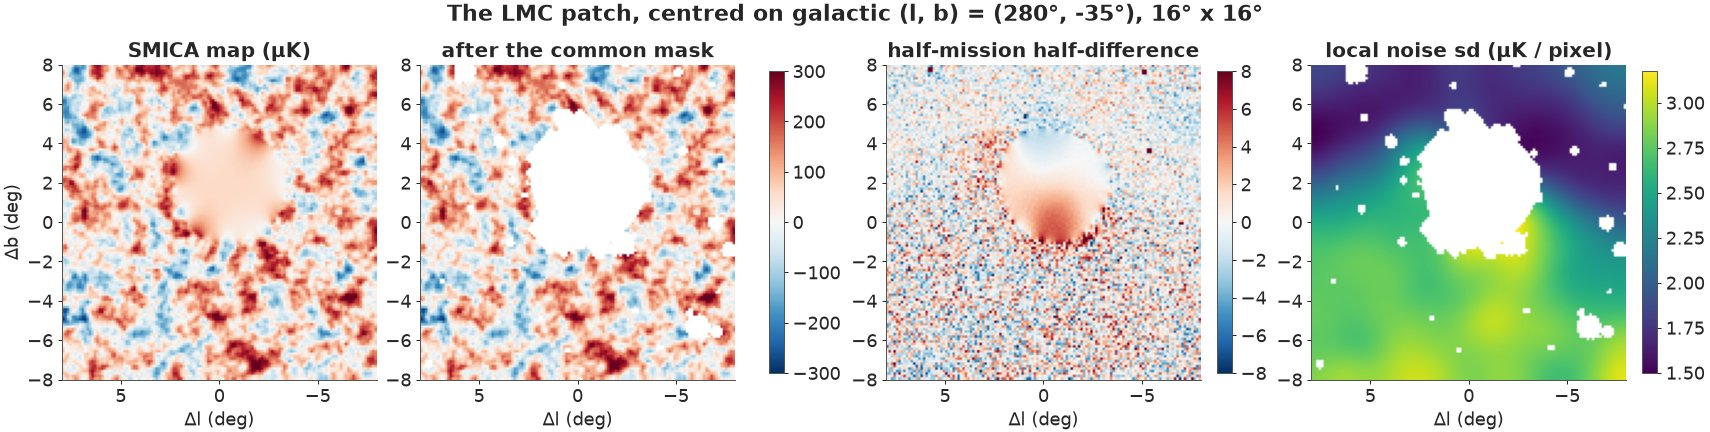

In [3]:
ext = [PATCH_DEG / 2, -PATCH_DEG / 2, -PATCH_DEG / 2, PATCH_DEG / 2]   # l decreases to the right
kw = dict(origin="lower", extent=ext, cmap="RdBu_r", vmin=-300, vmax=300)
fig, axs = plt.subplots(1, 4, figsize=(19, 4.8), layout="constrained")
im = axs[0].imshow(y_lmc, **kw)
axs[0].set_title("SMICA map (μK)")
axs[1].imshow(np.where(obs_lmc, y_lmc, np.nan), **kw)
axs[1].set_title("after the common mask")
im2 = axs[2].imshow(noise_lmc, origin="lower", extent=ext, cmap="RdBu_r", vmin=-8, vmax=8)
axs[2].set_title("half-mission half-difference")
im3 = axs[3].imshow(np.where(obs_lmc, sigma_lmc, np.nan), origin="lower", extent=ext, cmap="viridis")
axs[3].set_title("local noise sd (μK / pixel)")
for ax in axs:
    ax.set_xlabel("Δl (deg)")
axs[0].set_ylabel("Δb (deg)")
fig.colorbar(im, ax=axs[:2], shrink=0.8)
fig.colorbar(im2, ax=axs[2], shrink=0.8)
fig.colorbar(im3, ax=axs[3], shrink=0.8)
fig.suptitle("The LMC patch, centred on galactic (l, b) = (280°, -35°), 16° x 16°")
show_jpeg(fig)

The CMB is the mottled pattern of hot (red) and cold (blue) spots about a degree across, with an
rms of about 100 μK. In the middle of the map SMICA's value is a smooth blob that does not look
like CMB at all: that is the LMC region, and the mask removes it together with a few small holes
around bright sources - 16% of the pixels in all. The noise map shows how good Planck is: a few μK
per pixel against a 100 μK signal, plus a clear few-μK imprint inside the LMC region, where the
foreground residuals differ between the two halves of the mission (it is masked anyway). The noise level is **not uniform**: it falls from about
3 μK at the bottom of the patch to 1.5 μK at the top, because this patch is near the south
ecliptic pole, which Planck's scan crossed on every rotation. The north patch, far from the
poles, is about twice as noisy and has almost nothing masked.

## B. The CMB as a Gaussian random field

### A flat patch and its modes

On a patch 16 degrees across the curvature of the sphere is small, so we treat the patch as a
flat square and describe the map $T(\mathbf x)$ by its **Fourier modes**. A plane wave with wave
vector $\boldsymbol\ell$ has a wavelength of $2\pi/|\boldsymbol\ell|$ radians; the flat-sky
multipole $\ell = |\boldsymbol\ell|$ plays the role of the spherical-harmonic $\ell$ (the peak at
$\ell \approx 220$ is the famous one-degree scale).

The CMB is, to the precision of every test so far, a **statistically isotropic Gaussian random
field**: every Fourier mode is an independent Gaussian with mean 0 and a variance $C_\ell$ that
depends only on $|\boldsymbol\ell|$. So the power spectrum $C_\ell$ is *all* there is to know about
the statistics of the map. To keep everything real-valued we use the **Hartley** transform - the
real cousin of the Fourier transform, $H(\mathbf a) = \mathrm{Re}\,\mathcal F(\mathbf a) -
\mathrm{Im}\,\mathcal F(\mathbf a)$, with basis functions $\cos + \sin$ - under which a stationary
field has independent real coefficients $a_{\boldsymbol\ell} \sim \mathcal N(0, S_{\boldsymbol\ell})$
and the map is $T = H(\mathbf a)$. $H$ is its own inverse up to a factor $n^2$, and one FFT
computes it.

What reaches the map is not the sky itself. The telescope blurs it with a **beam** (SMICA's
effective beam is a 5 arcminute Gaussian), the HEALPix pixels average it (a **pixel window**), our
7.5' pixels average again (a **box**), and power at scales finer than the pixel grid can resolve
folds back onto the grid (**aliasing**). All four multiply the power of each mode, and the
function `folded_power` below adds them up for every mode of the grid.

A last flat-sky detail: the gnomonic projection magnifies the sky away from the centre (by
$\sec^{1.5}\theta$ on average, radial and tangential together), so a wave of a given length on the
plane is a slightly shorter wave on the sky. We correct plane multipoles by the mean
magnification over the patch.

In [4]:
ELL_T = np.concatenate([[0.0, 1.0], theory.ell.to_numpy(float)])
CL_T = np.concatenate([[0.0, 0.0], theory.TT.to_numpy() * 2 * np.pi / (theory.ell * (theory.ell + 1)).to_numpy()])
SIG_BEAM = P["beam_fwhm_arcmin"] * ARCMIN / np.sqrt(8 * np.log(2))
PIXWIN = P["pixwin_2048"]
h = np.deg2rad(PATCH_DEG / 2)
xx = np.linspace(-h, h, 401)
theta = np.arctan(np.hypot(xx[:, None], xx[None, :]))
STRETCH = float(np.mean(np.cos(theta) ** -1.5))
print(f"mean magnification of the gnomonic projection over the patch: {STRETCH:.4f}")


def cl_planck(ell):
    return np.interp(ell, ELL_T, CL_T, right=0.0)


def dl(ell, cl):
    return ell * (ell + 1) * cl / (2 * np.pi)


def kgrid(n, dx):
    k = 2 * np.pi * np.fft.fftfreq(n, dx)
    return k[:, None], k[None, :]


def beam_pixwin(ell):
    lc = np.clip(ell, 0, len(PIXWIN) - 1)
    return np.exp(-0.5 * lc**2 * SIG_BEAM**2) * np.interp(lc, np.arange(len(PIXWIN)), PIXWIN)


def box(k, dx, nsub=NSUB):
    """Transfer function of averaging nsub point samples spaced dx / nsub (one model pixel)."""
    x = k * dx / nsub / 2
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.sin(nsub * x) / (nsub * np.sin(x))
    return np.where(np.abs(np.sin(x)) < 1e-12, np.cos(nsub * x) / np.cos(x), out)


def folded_power(n, dx, stretch=STRETCH, nalias=3):
    """Expected power of the beamed, pixel-averaged sky at every mode of an n x n grid, including the
    power aliased from beyond the Nyquist frequency (the sum over k + m 2 pi / dx)."""
    kx, ky = kgrid(n, dx)
    K = 2 * np.pi / dx
    tot = np.zeros((n, n))
    for mx in range(-nalias, nalias + 1):
        for my in range(-nalias, nalias + 1):
            qx, qy = kx + mx * K, ky + my * K
            ell = np.hypot(qx, qy) * stretch                   # plane wavenumber -> sky multipole
            tot += stretch**2 * cl_planck(ell) * (beam_pixwin(ell) * box(qx, dx) * box(qy, dx)) ** 2
    return tot


def hartley(a):
    f = sf.fft2(a, axes=(-2, -1), workers=4)
    return f.real - f.imag


def simulate_sky(rng, cl_scale=None, stretch=STRETCH, big=1536):
    """A Gaussian sky made the way the data were: drawn on a large torus of 0.94' samples (24 deg),
    beamed, averaged in 8 x 8 blocks, and the central 128 x 128 pixels cut out (so NOT periodic).
    Returns (the map as Planck would see it, the same sky without beam)."""
    dxf = RESO / NSUB
    kx, ky = kgrid(big, dxf)
    ell = np.hypot(kx, ky) * stretch
    cl = stretch**2 * cl_planck(ell) * (1.0 if cl_scale is None else cl_scale(ell))
    amp = np.sqrt(cl) / dxf * rng.standard_normal((big, big))
    nb = big // NSUB
    c0 = (nb - N_OBS) // 2
    out = []
    for w in (beam_pixwin(ell), 1.0):
        s = (hartley(w * amp) / big).reshape(nb, NSUB, nb, NSUB).mean(axis=(1, 3))
        out.append(s[c0:c0 + N_OBS, c0:c0 + N_OBS])
    return out


sims = [simulate_sky(np.random.default_rng(RANDOM_SEED + i))[0] for i in range(2)]

mean magnification of the gnomonic projection over the patch: 1.0098


### Is the real sky just a random draw?

Two skies drawn from the Planck spectrum (made the way the data were made, with noise added) next
to the real north patch - and, to see what the power spectrum does *not* know, the real patches
with their Fourier **phases** scrambled: every mode keeps its amplitude, so the power spectrum is
unchanged, but the positions are randomised.

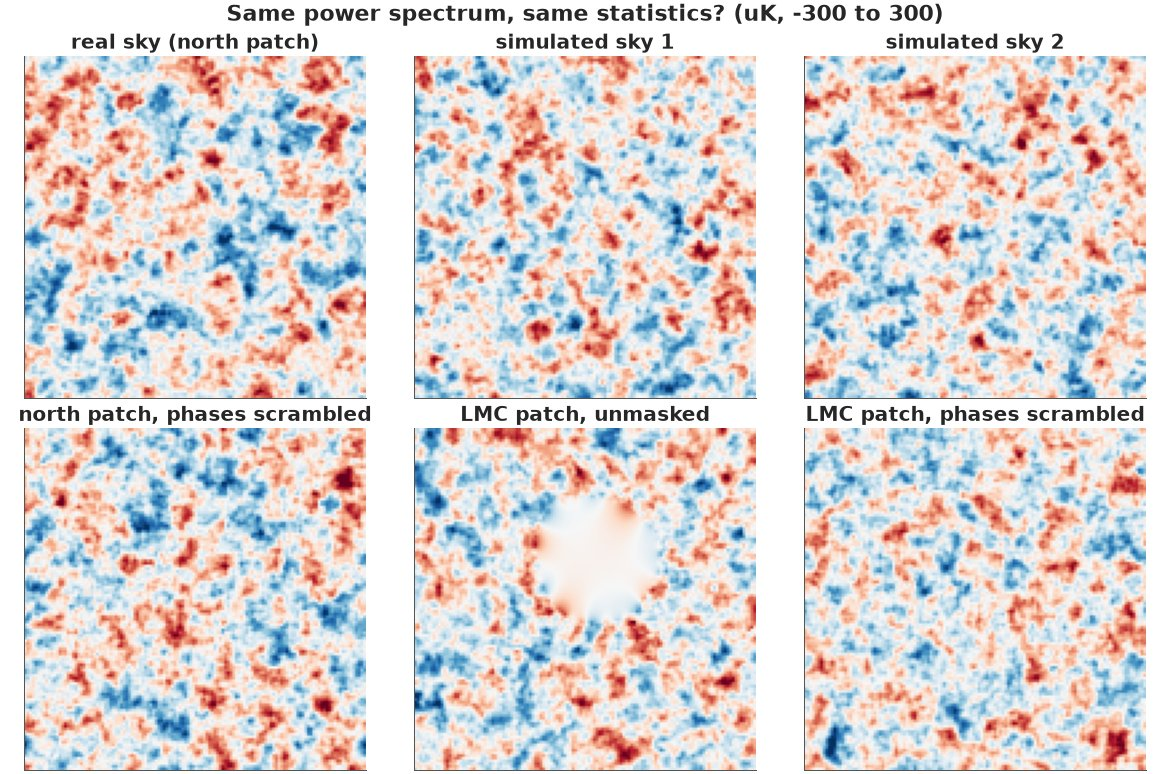

In [5]:
def scramble(x, rng):
    f = np.fft.rfft2(x - x.mean())
    f = np.abs(f) * np.exp(2j * np.pi * rng.random(f.shape))
    return np.fft.irfft2(f, s=x.shape)


fig, axs = plt.subplots(2, 3, figsize=(13, 8.6), layout="constrained")
panels = [(y_nth, "real sky (north patch)"), (sims[0] + sigma_nth * rng.standard_normal(y_nth.shape),
                                              "simulated sky 1"),
          (sims[1] + sigma_nth * rng.standard_normal(y_nth.shape), "simulated sky 2"),
          (scramble(y_nth, rng), "north patch, phases scrambled"), (y_lmc, "LMC patch, unmasked"),
          (scramble(y_lmc, rng), "LMC patch, phases scrambled")]
for ax, (img, title) in zip(axs.ravel(), panels):
    ax.imshow(img - img.mean(), **kw)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Same power spectrum, same statistics? (uK, -300 to 300)")
show_jpeg(fig)

The simulated skies and the real north patch are indistinguishable by eye, and scrambling the
phases of the north patch gives another equally CMB-like sky: for a Gaussian field the phases are
random, so they carry no information about the physics and the power spectrum is a **sufficient
statistic**. Now the unmasked LMC patch: its smooth disc - where SMICA's CMB estimate is not CMB at
all - is obvious in the map, but after scrambling it has vanished into an ordinary-looking sky. What
made it recognisable was entirely in its phases: *where* the power is. A power spectrum cannot tell
a localised foreground from CMB; a map can.

So *when* is the power spectrum enough? For a Gaussian field observed **everywhere, with uniform
noise** (full sky, or a periodic flat patch), the likelihood factorises over modes and depends on
the data only through the power in each band: the field-level posterior for $C_\ell$ and the
power-spectrum posterior are the same thing (Part D checks this numerically). A mask, noise that
varies across the map and foreground residuals all break that factorisation, and those are the
reasons to work at the level of the map.

## C. The summary-statistic route, and how it fails

The obvious estimate: fill the masked pixels with zero, Fourier-transform, average $|\hat T_{\boldsymbol
\ell}|^2$ in rings of $\ell$ and divide by the fraction of the sky used. Then subtract the noise
power (measured the same way on a noise map) and divide by what the beam, the pixel windows and
aliasing do to each mode. A common improvement is to **taper** the weights smoothly to zero at the mask and patch edges. The
test is simulations with a known truth: 30 Planck-spectrum skies with the LMC mask and noise.

In [6]:
EDGES = np.array([0, 60, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800,
                  850, 900, 1000, 1100, 1200, 1300, 1450, 1600, 1800, 2100])
ELL_B = 0.5 * (EDGES[1:] + EDGES[:-1])
NB = len(ELL_B)
kx0, ky0 = kgrid(N_OBS, RESO)
ELL_GRID = np.hypot(kx0, ky0) * STRETCH
BIN_GRID = np.digitize(ELL_GRID, EDGES) - 1
# what the beam, both pixel windows and aliasing do to each mode (a transfer function, as in practice
# estimated from simulations): folded power / sky power
with np.errstate(invalid="ignore", divide="ignore"):
    WIN2 = folded_power(N_OBS, RESO) / (STRETCH**2 * cl_planck(ELL_GRID))
# the "truth" for a bandpower: the Planck D_ell averaged over the modes of the bin
DL_PLANCK_B = np.array([dl(ELL_GRID, cl_planck(ELL_GRID))[BIN_GRID == b].mean() for b in range(NB)])


def ring_average(P2):
    sel = (BIN_GRID >= 0) & (BIN_GRID < NB)
    return np.bincount(BIN_GRID[sel], P2[sel], NB) / np.bincount(BIN_GRID[sel], minlength=NB)


def naive_dl(x, w, noise=None):
    """Pseudo-spectrum of the weighted map, / mean(w^2), minus the noise pseudo-spectrum, / windows."""
    def pseudo(z):
        zw = w * (z - np.sum(w * z) / np.sum(w))
        return np.abs(np.fft.fft2(zw)) ** 2 * RESO**2 / N_OBS**2 / np.mean(w**2) * STRETCH**-2
    P2 = pseudo(x)
    if noise is not None:
        P2 = P2 - pseudo(noise)
    return ring_average(np.where(ELL_GRID > 0, dl(ELL_GRID, P2) / WIN2, 0.0))


taper1 = np.sin(np.linspace(0, np.pi, N_OBS)) ** 0.5
w_taper = ndimage.gaussian_filter(obs_lmc.astype(float), 3) * obs_lmc * np.outer(taper1, taper1)
t0 = time.time()
ratios = {"sharp mask": [], "tapered": []}
for i in range(30):
    r = np.random.default_rng(1000 + i)
    s = simulate_sky(r)[0]
    nz = sigma_lmc * r.standard_normal(s.shape)
    nz2 = sigma_lmc * r.standard_normal(s.shape)            # an independent noise map, as from half-mission
    for name, w in [("sharp mask", obs_lmc.astype(float)), ("tapered", w_taper)]:
        ratios[name].append(naive_dl(s + nz, w, noise=nz2) / DL_PLANCK_B)
naive_real = naive_dl(y_lmc, obs_lmc.astype(float), noise=noise_lmc)
naive_real_taper = naive_dl(y_lmc, w_taper, noise=noise_lmc)
tab = pd.DataFrame({"ell": ELL_B, **{f"{k}: mean ratio in sims": np.mean(v, 0) for k, v in ratios.items()},
                    **{f"{k}: sd": np.std(v, 0) for k, v in ratios.items()}})
print(f"30 simulations in {time.time() - t0:.1f} s")
print(tab.round(2).iloc[::2].to_string(index=False))

30 simulations in 1.8 s
   ell  sharp mask: mean ratio in sims  tapered: mean ratio in sims  sharp mask: sd  tapered: sd
  30.0                            1.08                         1.12            0.34         0.34
 125.0                            0.96                         0.97            0.16         0.21
 225.0                            0.97                         0.99            0.13         0.17
 325.0                            1.10                         1.08            0.13         0.15
 425.0                            1.20                         1.07            0.12         0.11
 525.0                            1.08                         1.02            0.09         0.08
 625.0                            1.16                         1.08            0.10         0.09
 725.0                            1.14                         1.06            0.09         0.09
 825.0                            1.11                         1.04            0.09         0.07
 950.0

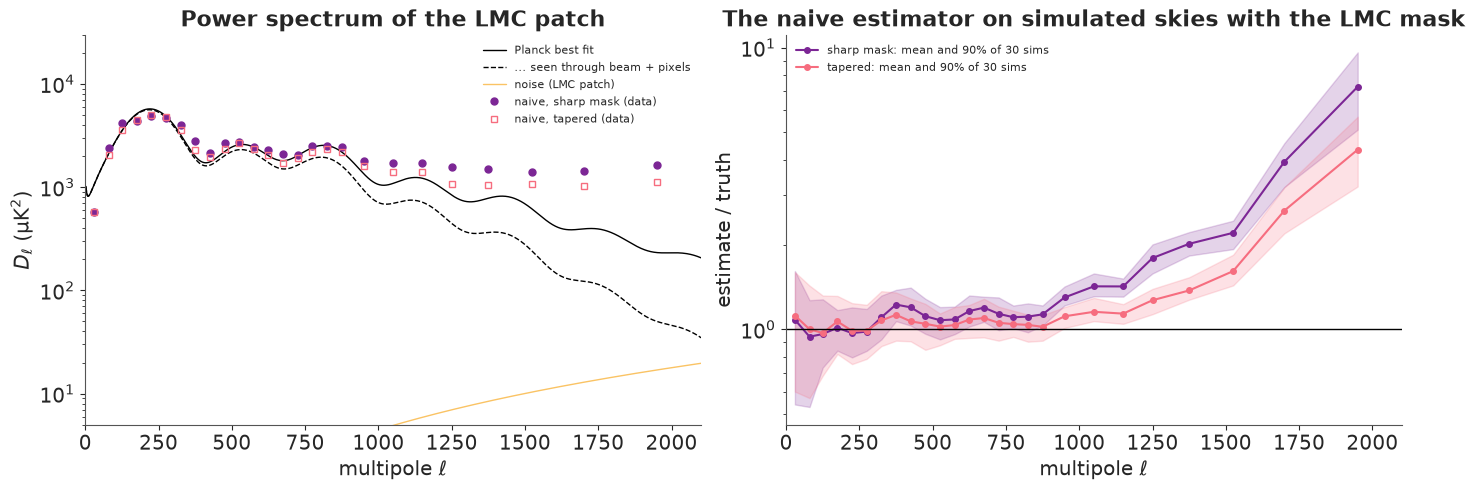

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), layout="constrained")
ell = np.arange(2, 2500)
ax = axs[0]
ax.plot(ell, dl(ell, cl_planck(ell)), "k", lw=1, label="Planck best fit")
ax.plot(ell, dl(ell, cl_planck(ell)) * beam_pixwin(ell) ** 2, "k--", lw=1, label="... seen through beam + pixels")
nl = np.mean(sigma_lmc[obs_lmc] ** 2) * RESO**2
ax.plot(ell, dl(ell, nl), "C2", lw=1, label="noise (LMC patch)")
ax.plot(ELL_B, naive_real, "o", color="C3", ms=5, label="naive, sharp mask (data)")
ax.plot(ELL_B, naive_real_taper, "s", color="C1", ms=4, mfc="none", label="naive, tapered (data)")
ax.set(yscale="log", ylim=(5, 3e4), xlim=(0, 2100), xlabel=r"multipole $\ell$", ylabel=r"$D_\ell$ (μK$^2$)",
       title="Power spectrum of the LMC patch")
ax.legend(fontsize=8)
ax = axs[1]
for (name, v), c in zip(ratios.items(), ["C3", "C1"]):
    v = np.array(v)
    ax.fill_between(ELL_B, np.quantile(v, 0.05, 0), np.quantile(v, 0.95, 0), color=c, alpha=0.2)
    ax.plot(ELL_B, v.mean(0), "o-", color=c, ms=4, label=f"{name}: mean and 90% of 30 sims")
ax.axhline(1, color="k", lw=1)
ax.set(yscale="log", xlabel=r"multipole $\ell$", ylabel="estimate / truth", xlim=(0, 2100),
       title="The naive estimator on simulated skies with the LMC mask")
ax.legend(fontsize=8);

On simulations where the truth is known, the sharp-mask estimate is right around the first peak,
10-20% too high from $\ell \approx 350$, 40% too high by $\ell \approx 1100$, twice the truth at
$\ell \approx 1400$ and four times at 1700. The edges of the mask and of the patch are sharp steps
of ~100 μK, and a step has power at *all* scales: power from the strong large scales **leaks** into
the weak small ones, and dividing by the beam amplifies what leaked. On the real data (left) the
same estimate levels off at 1,500-1,700 μK² above $\ell \approx 1000$ instead of following the
damping tail down.

Tapering the weights helps - within about 15% of the truth up to $\ell \approx 1200$ - but is
still 1.4 times too high at $\ell \approx 1400$ and about 4 times in the top bin, throws away data near every hole, mixes neighbouring
$\ell$ (the taper's own window), and has no error bars unless you run simulations like these. The professional version (e.g. MASTER, Hivon et al.
2002) inverts the mode-coupling matrix of the mask and calibrates everything with simulations. That
works, but notice what we have been doing: correcting a summary statistic for the ways in which the
data are *not* a clean, full, uniformly noisy Gaussian field. A model of the map, with the mask and
the noise in the likelihood, needs no corrections at all.

## D. A field-level model in PyMC

### The model

The unknowns are the sky's Hartley coefficients $\mathbf a$ (one per pixel) and the power
spectrum, written as the log ratio $q_b$ of the bandpower in bin $b$ to the Planck value:

$$a_{\boldsymbol\ell} \sim \mathcal N\!\left(0,\; S_{\boldsymbol\ell}\, e^{q_{b(\ell)}}\right),
\qquad y_{\mathbf x} \sim \mathcal N\!\left(H(\mathbf a)_{\mathbf x},\; \sigma_{\mathbf x}^2\right)
\quad\text{for every usable pixel } \mathbf x,$$

where $S_{\boldsymbol\ell}$ is the Planck power seen through the beam and pixels, and masked
pixels simply have no likelihood term. That is the whole model: the mask and uneven noise enter
exactly, with no corrections.

We start on a problem where the answer is known exactly: a simulated **periodic** 64 x 64 patch of
15' pixels with no mask and uniform noise. There the power-spectrum posterior can be computed
mode by mode on a grid (Part B's sufficiency), so we can check the sampler. The Hartley transform
of a 64 x 64 map is four 64 x 64 matrix products, which keeps the model in plain PyTensor (fast
under nutpie's default Numba backend).

### Centred or non-centred?

There are two natural ways to write the prior of the field, familiar from hierarchical models
(E02): **centred**, sample $a$ itself with sd $\sqrt{S e^{q}}$; or **non-centred**, sample $z \sim
\mathcal N(0, 1)$ and set $a = \sqrt{S e^q}\,z$. Which one is right depends on the signal-to-noise
ratio of the mode, and a CMB map contains modes of *both* kinds. **Partial non-centring**
(Papaspiliopoulos, Roberts & Sköld 2007) interpolates: sample $v = a / (S e^q)^{w/2}$ with
$w = 1/(1 + \mathrm{S/N})$, which is centred where the data dominate and non-centred where the
prior does. We fit all three, at Planck's noise level and at 30 times Planck's noise.

In [8]:
N_S, RESO_S = 64, 15.0 * ARCMIN
kxs, kys = kgrid(N_S, RESO_S)
ell_s = np.hypot(kxs, kys)
W_S = beam_pixwin(ell_s) * box(kxs, RESO_S) * box(kys, RESO_S)
S_S = cl_planck(ell_s) * W_S**2 / (RESO_S * N_S) ** 2        # Hartley variance of the beamed sky
S_S[0, 0] = 100.0**2
EDGES_S = np.array([0, 60, 120, 180, 240, 300, 360, 420, 480, 560, 640, 720, 820, 1020])
ELL_S = 0.5 * (EDGES_S[1:] + EDGES_S[:-1])
bin_s = np.digitize(ell_s, EDGES_S) - 1
bin_s[0, 0] = -1
rs = np.random.default_rng(5)
a_true = np.sqrt(S_S) * rs.standard_normal((N_S, N_S))
eps = rs.standard_normal((N_S, N_S))
SIG_PLANCK_15 = np.median(sigma_lmc[obs_lmc]) / 2              # same noise power per area at 15' pixels
j = np.arange(N_S)
FC = np.cos(2 * np.pi * np.outer(j, j) / N_S)
FS = np.sin(2 * np.pi * np.outer(j, j) / N_S)
assert np.allclose(FC @ eps @ FC - FS @ eps @ FS + FC @ eps @ FS + FS @ eps @ FC, hartley(eps))


def field_model(y, sig, param, observed=None):
    """The field-level model on the 64 x 64 periodic patch. param: 'centred', 'non-centred', 'partial'."""
    observed = np.ones_like(y, bool) if observed is None else observed
    idx = np.flatnonzero(observed)
    sn = S_S * N_S**2 / sig**2
    w = {"centred": np.zeros_like(sn), "non-centred": np.ones_like(sn), "partial": 1 / (1 + sn)}[param]
    w[0, 0] = 0.0
    coords = {"bin": ELL_S, "row": np.arange(N_S), "col": np.arange(N_S)}
    with pm.Model(coords=coords) as m:
        q = pm.Normal("q", 0, 3, dims="bin")
        log_sd = 0.5 * np.log(S_S) + 0.5 * pt.where(bin_s >= 0, q[np.maximum(bin_s, 0)], 0.0)
        v = pm.Normal("v", 0, pt.exp((1 - w) * log_sd), dims=("row", "col"))
        a = pt.exp(w * log_sd) * v
        sky = FC @ a @ FC - FS @ a @ FS + FC @ a @ FS + FS @ a @ FC
        pm.Normal("y", mu=sky.ravel()[idx], sigma=sig, observed=y.ravel()[idx])
    return m


def exact_q_posterior(y, sig):
    """Mode by mode: Hartley coefficient Y_k of the map ~ N(0, n^4 S_k e^q + n^2 sig^2)."""
    Yk = hartley(y)
    grid = np.linspace(-4, 4, 4001)
    out = []
    for b in range(len(ELL_S)):
        sel = bin_s == b
        var = np.exp(grid)[:, None] * (S_S * N_S**4)[sel][None] + sig**2 * N_S**2
        lp = -0.5 * np.sum(np.log(var) + Yk[sel][None] ** 2 / var, axis=1) - grid**2 / 18
        p = np.exp(lp - lp.max())
        p /= p.sum()
        mu = (p * grid).sum()
        out.append((mu, np.sqrt((p * (grid - mu) ** 2).sum())))
    return np.array(out)


fits, rows = {}, []
for noise_x in (1, 30):
    sig = SIG_PLANCK_15 * noise_x
    y_s = hartley(a_true) + sig * eps
    exact = exact_q_posterior(y_s, sig)
    for param in (["non-centred", "centred", "partial"] if noise_x == 1 else ["centred", "non-centred", "partial"]):
        t0 = time.time()
        idata = pm.sample(model=field_model(y_s, sig, param), random_seed=RANDOM_SEED, progressbar=False)
        dt = time.time() - t0
        post = idata.posterior["q"]
        ess = az.ess(idata, var_names=["q"])["q"].values
        rhat = az.rhat(idata, var_names=["q"])["q"].values
        err = np.abs(post.mean(("chain", "draw")).values - exact[:, 0]) / exact[:, 1]
        fits[(noise_x, param)] = ess
        rows.append({"noise": f"{noise_x} x Planck", "prior": param, "seconds": round(dt, 1),
                     "divergences": int(idata.sample_stats["diverging"].sum()),
                     "max r_hat": rhat.max(), "min ESS": ess.min(),
                     "worst |mean - exact| / exact sd": err.max(),
                     "sd / exact sd (median)": np.median(post.std(("chain", "draw")).values / exact[:, 1])})
        del idata
print(pd.DataFrame(rows).round(2).to_string(index=False))

      noise       prior  seconds  divergences  max r_hat  min ESS  worst |mean - exact| / exact sd  sd / exact sd (median)
 1 x Planck non-centred      7.2            0       3.65     4.37                             3.15                    1.04
 1 x Planck     centred      3.8            0       1.00  4266.68                             0.03                    0.99
 1 x Planck     partial      4.4            0       1.00  4043.57                             0.03                    0.99
30 x Planck     centred      8.7            0       1.25    12.15                             0.62                    1.01
30 x Planck non-centred      5.5            0       1.03   254.21                             0.11                    0.99
30 x Planck     partial      4.8            0       1.00  1080.43                             0.04                    0.98


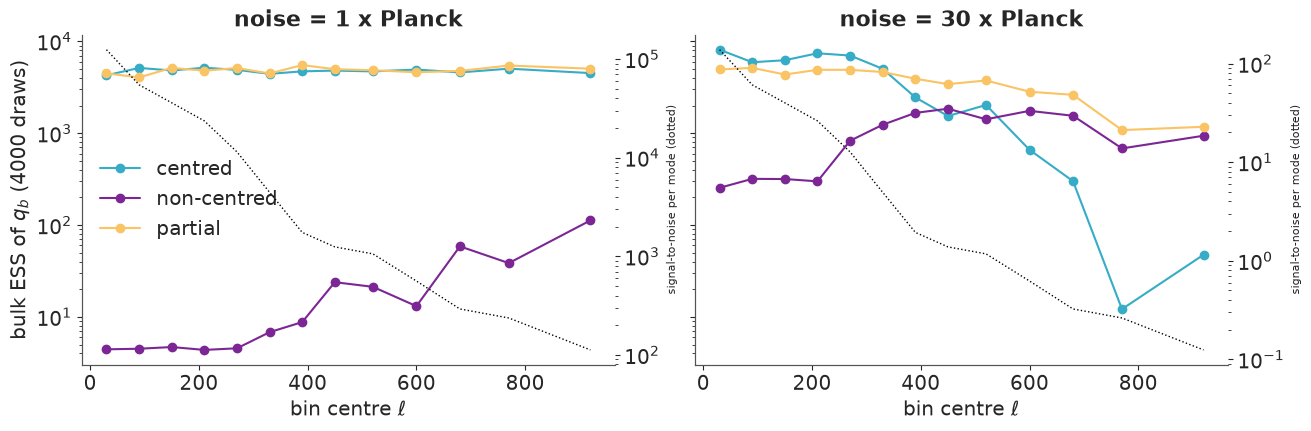

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), layout="constrained", sharey=True)
for ax, noise_x in zip(axs, (1, 30)):
    for param, c in zip(["centred", "non-centred", "partial"], ["C0", "C3", "C2"]):
        ax.plot(ELL_S, fits[(noise_x, param)], "o-", color=c, label=param)
    sn_bin = [np.median((S_S * N_S**2 / (SIG_PLANCK_15 * noise_x) ** 2)[bin_s == b]) for b in range(len(ELL_S))]
    ax2 = ax.twinx()
    ax2.plot(ELL_S, sn_bin, "k:", lw=1)
    ax2.set_yscale("log")
    ax2.set_ylabel("signal-to-noise per mode (dotted)", fontsize=8)
    ax.set(yscale="log", xlabel=r"bin centre $\ell$", title=f"noise = {noise_x} x Planck")
axs[0].set_ylabel("bulk ESS of $q_b$ (4000 draws)")
axs[0].legend();

This is the famous problem, both ways round, with **zero divergences** in every fit:

* At Planck's noise level every mode has a signal-to-noise ratio above 100 (dotted line, up to
  $10^5$). The data pin the sky down, so in the non-centred version $z = a/\sqrt{S e^q}$ must change
  whenever $q$ does: $q$ and hundreds of $z$'s can only move together, along a thin ridge. The
  chains barely move (r_hat above 3, ESS in single or double figures) and bin means land 2-3
  exact sds away from the truth.
  Centred, the same model gives ESS over 4,000 in every bin and agrees with the exact posterior to
  0.03 sd.
* At 30 times the noise, the top bins become noise-dominated (S/N per mode below 1). There the
  data say little about each mode and the centred version is a funnel: a small $q$ forces all the
  $a$'s of the bin to be small. Its ESS collapses to 12 (r_hat 1.25) in exactly those bins. The
  non-centred version now copes (minimum ESS about 250), weakest in the large-scale bins that are
  still data-dominated.
* The partially non-centred version, with each mode's weight set by its expected S/N, works in
  both regimes (minimum ESS about 1,000 and 4,000) and matches the exact posterior everywhere.

And the bandpower posteriors from the field-level model agree with the exact power-spectrum
posterior: with no mask and uniform noise, the map carries no information about $C_\ell$ beyond
its power spectrum, as promised.

### What a mask does to HMC

Now give the same simulated patch the LMC mask. Nothing else changes.

In [10]:
obs_s = block(obs_lmc.astype(float), 2) == 1
y_s = hartley(a_true) + SIG_PLANCK_15 * eps
t0 = time.time()
idata_hole = pm.sample(model=field_model(y_s, SIG_PLANCK_15, "partial", observed=obs_s), tune=100,
                       draws=50, chains=2, random_seed=RANDOM_SEED, progressbar=False)
depth = idata_hole.sample_stats["depth"].values
print(f"{time.time() - t0:.0f} s; tree depth: mean {depth.mean():.1f}, max {depth.max()} "
      f"(= {2 ** depth.max() - 1} gradient evaluations per draw); divergences "
      f"{int(idata_hole.sample_stats['diverging'].sum())}")
print(f"unmasked fits above: {rows[2]['seconds']} s for 4 chains x 1400 iterations")
del idata_hole

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


14 s; tree depth: mean 10.0, max 10 (= 1023 gradient evaluations per draw); divergences 0
unmasked fits above: 4.4 s for 4 chains x 1400 iterations


Every draw now hits NUTS's maximum tree depth: over a thousand gradient evaluations per draw
instead of a few dozen. The reason is **conditioning**. The diagonal mass matrix that nutpie adapts
is diagonal *in Hartley space*, which is right when every mode is seen equally. A hole breaks that:
a pattern that lives inside the hole is constrained only by the prior (sd ~ $\sqrt S$), while the
same Hartley modes are pinned to within the noise by the rest of the map. The ratio of those
scales is the signal-to-noise ratio - up to $10^5$ for the largest scales here - and the number of
leapfrog steps HMC needs grows like its square root. The patch edges cause the same problem:
a real map is not periodic, so the model's field has to live on a slightly larger torus with an
unobserved border (while building this notebook we checked that without one, the wrap-around seam
fakes small-scale power: up to twice the true power above $\ell \approx 1500$).

## E. The real sky: the Gibbs sampler

The classic answer (Wandelt, Larson & Lakshminarayanan 2004; Eriksen et al. 2004; Jewell, Levin &
Anderson 2004) alternates two exact conditional draws:

1. **The sky given the spectrum.** $\mathbf a \mid q, \mathbf y$ is Gaussian with precision
   $S_q^{-1} + A^\top N^{-1} A$ ($A$: coefficients to observed pixels). A draw is the solution of
   one linear system,
   $$\left(S_q^{-1} + A^\top N^{-1} A\right)\mathbf a = A^\top N^{-1}\mathbf y + S_q^{-1/2}\boldsymbol\omega_1
   + A^\top N^{-1/2}\boldsymbol\omega_2, \qquad \boldsymbol\omega_i \sim \mathcal N(0, I),$$
   a **constrained realisation**; without the $\boldsymbol\omega$'s it is the **Wiener filter**, the
   posterior mean. We solve it by **conjugate gradients**, which needs only products with the
   matrix: two FFTs each. The same conditioning that hurt HMC slows CG down, so we use Eriksen et
   al.'s preconditioner: exact (a dense matrix) for the ~700 modes with $\ell < 300$, diagonal above.
2. **The spectrum given the sky.** With a flat prior on each $q_b$, $e^{q_b}$ is inverse-gamma with
   shape $n_b/2$ and scale $\frac12\sum_{k\in b} a_k^2/S_k$ - the sky's own power in the bin.

This is the **centred** scheme, so it inherits the centred problem in noise-dominated bins. Jewell
et al.'s fix is a third, **non-centred** move: propose a new $q_b$ and rescale the bin's modes with
it, $a_k \to a_k e^{(q_b' - q_b)/2}$; the prior and the Jacobian cancel, and a Metropolis step on
the likelihood decides. It is rejected where the data pin the sky, and accepted where they do not.

The torus is 144 x 144 pixels: the 128 x 128 map plus an 8-pixel (1°) unobserved border. The prior
power $S$ is the folded Planck spectrum of Part B, noise is the local map of Part A, and masked
pixels simply have $N^{-1} = 0$.

In [11]:
class FieldSampler:
    """Gibbs sampler for (sky, bandpowers) of a masked map with pixel noise sigma, several chains at once."""

    def __init__(self, observed, sigma, edges=EDGES, pad=8, ell_dense=300.0, stretch=STRETCH):
        self.pad = pad
        nt = self.nt = N_OBS + 2 * pad
        kx, ky = kgrid(nt, RESO)
        self.ell = np.hypot(kx, ky) * stretch
        self.S0 = folded_power(nt, RESO, stretch=stretch) / (RESO * nt) ** 2         # Hartley variance at q = 0
        self.S0[0, 0] = 100.0**2                                    # patch mean: prior sd 100 uK
        self.bin = np.digitize(self.ell, edges) - 1
        self.bin[0, 0] = -1
        self.nb = len(edges) - 1
        self.nk = np.bincount(self.bin[self.bin >= 0], minlength=self.nb)
        self.Ninv = np.zeros((nt, nt))
        self.Ninv[pad:pad + N_OBS, pad:pad + N_OBS] = np.where(observed, sigma**-2.0, 0.0)
        self.data_diag = nt**2 * self.Ninv.mean()
        # dense block of A^T N^-1 A for the large scales (it does not depend on q: compute once)
        self.low = np.flatnonzero(self.ell.ravel() < ell_dense)
        E = np.zeros((len(self.low), nt * nt))
        E[np.arange(len(self.low)), self.low] = 1.0
        blocks = [self.AtNA(e.reshape(-1, nt, nt)).reshape(len(e), -1)[:, self.low]
                  for e in np.array_split(E, max(1, len(E) // 128))]
        self.AtNA_low = np.concatenate(blocks)
        sn = self.S0 * self.data_diag
        self.step = np.array([np.sqrt(2 / self.nk[b]) * (1 + 1 / np.median(sn[self.bin == b]))
                              for b in range(self.nb)])

    def AtNA(self, a):
        return hartley(self.Ninv * hartley(a))

    def embed(self, y):
        Y = np.zeros(y.shape[:-2] + (self.nt, self.nt))
        Y[..., self.pad:self.pad + N_OBS, self.pad:self.pad + N_OBS] = y
        return Y

    def prior_var(self, q):
        return self.S0[None] * np.where(self.bin < 0, 1.0, np.exp(q)[:, np.maximum(self.bin, 0)])

    def solve(self, q, Y, rng=None, tol=1e-5, maxit=5000):
        """Wiener filter (rng=None) or constrained realisation, by preconditioned conjugate gradients."""
        S = self.prior_var(q)
        nc = len(S)
        b = hartley(self.Ninv * Y)
        if rng is not None:
            b = b + rng.standard_normal(S.shape) / np.sqrt(S) + hartley(np.sqrt(self.Ninv) * rng.standard_normal(S.shape))
        diag = 1 / (1 / S + self.data_diag)
        low = self.low
        inv_low = np.array([np.linalg.inv(self.AtNA_low + np.diag(1 / S[c].ravel()[low])) for c in range(nc)])

        def precondition(r):
            z = diag * r
            z.reshape(nc, -1)[:, low] = np.matmul(inv_low, r.reshape(nc, -1)[:, low, None])[..., 0]
            return z

        x = np.zeros_like(S)
        r = b.copy()
        z = precondition(r)
        p = z.copy()
        rz = np.sum(r * z, axis=(1, 2), keepdims=True)
        bnorm = np.linalg.norm(b.reshape(nc, -1), axis=1)
        for it in range(1, maxit + 1):
            Ap = p / S + self.AtNA(p)
            alpha = rz / np.sum(p * Ap, axis=(1, 2), keepdims=True)
            x += alpha * p
            r -= alpha * Ap
            if np.max(np.linalg.norm(r.reshape(nc, -1), axis=1) / bnorm) < tol:
                break
            z = precondition(r)
            rz_new = np.sum(r * z, axis=(1, 2), keepdims=True)
            p = z + rz_new / rz * p
            rz = rz_new
        return x, it

    def draw_q(self, a, rng):
        keep = self.bin.ravel() >= 0
        r = (a**2 / self.S0[None]).reshape(len(a), -1)[:, keep]
        ssum = np.array([np.bincount(self.bin.ravel()[keep], weights=rc, minlength=self.nb) for rc in r])
        return np.log(ssum / 2 / rng.gamma(self.nk / 2, 1.0, size=ssum.shape)), ssum

    def rescale(self, a, q, Y, rng):
        Ha = hartley(a)
        loglik = -0.5 * np.sum(self.Ninv * (Y - Ha) ** 2, axis=(1, 2))
        acc = np.zeros((len(a), self.nb))
        for b in rng.permutation(self.nb):
            inb = self.bin == b
            step = self.step[b] * rng.standard_normal(len(a))
            f = np.exp(step / 2) - 1
            dHa = f[:, None, None] * hartley(np.where(inb, a, 0.0))
            new = -0.5 * np.sum(self.Ninv * (Y - Ha - dHa) ** 2, axis=(1, 2))
            ok = np.log(rng.random(len(a))) < new - loglik
            a[ok] = a[ok] * np.where(inb, 1 + f[ok, None, None], 1.0)
            Ha[ok] += dHa[ok]
            q[ok, b] += step[ok]
            loglik[ok] = new[ok]
            acc[:, b] = ok
        return a, q, acc

    def run(self, y, n_iter, rng, q0, keep_maps=0, tol=1e-5):
        """y: one map (all chains see it) or one map per chain. Returns draws of q, CG counts,
        acceptance of the rescaling move, per-chain mean and sd of the sky, and a few sky draws."""
        Y = self.embed(y) if y.ndim == 3 else np.broadcast_to(self.embed(y), (len(q0), self.nt, self.nt))
        q = q0.copy()
        out = {"q": [], "cg": [], "acc": []}
        s1 = s2 = 0.0
        maps = []
        burn = n_iter // 5
        for i in range(n_iter):
            a, it = self.solve(q, Y, rng, tol=tol)
            q, _ = self.draw_q(a, rng)
            a, q, acc = self.rescale(a, q, Y, rng)
            out["q"].append(q.copy())
            out["cg"].append(it)
            out["acc"].append(acc)
            if i >= burn:
                t = hartley(a)
                s1, s2 = s1 + t, s2 + t**2
                if i >= n_iter - keep_maps:
                    maps.append(t[:, self.pad:self.pad + N_OBS, self.pad:self.pad + N_OBS].copy())
        out = {k: np.array(v) for k, v in out.items()}
        n = n_iter - burn
        out["mean"], out["sq"], out["maps"], out["burn"] = s1 / n, s2 / n, np.array(maps), burn
        return out


t0 = time.time()
gibbs = FieldSampler(obs_lmc, sigma_lmc)
print(f"set-up {time.time() - t0:.1f} s: torus {gibbs.nt}^2 = {gibbs.nt ** 2:,} sky parameters, "
      f"{gibbs.nb} bandpowers, dense preconditioner on {len(gibbs.low)} modes")
t0 = time.time()
res = gibbs.run(y_lmc, 80, np.random.default_rng(RANDOM_SEED), q0=rng.normal(0, 0.3, (4, gibbs.nb)),
                keep_maps=40)
print(f"4 chains x 80 iterations in {time.time() - t0:.0f} s; CG iterations per constrained realisation: "
      f"median {np.median(res['cg']):.0f}")
post_q = res["q"][res["burn"]:]                          # (draw, chain, bin)
ds_q = xr.Dataset({"q": (("chain", "draw", "ell"), post_q.transpose(1, 0, 2))}, coords={"ell": ELL_B})
diag_tab = pd.DataFrame({"ell": ELL_B, "q mean": post_q.mean((0, 1)), "q sd": post_q.std((0, 1)),
                         "r_hat": az.rhat(ds_q)["q"].values, "ess_bulk": az.ess(ds_q)["q"].values,
                         "rescale acceptance": res["acc"].mean((0, 1))})
print(diag_tab.round(3).to_string(index=False))

set-up 0.1 s: torus 144^2 = 20,736 sky parameters, 26 bandpowers, dense preconditioner on 681 modes


4 chains x 80 iterations in 27 s; CG iterations per constrained realisation: median 366
   ell  q mean  q sd  r_hat  ess_bulk  rescale acceptance
  30.0  -0.255 0.341  1.009   178.472               0.006
  80.0   0.334 0.232  1.004   204.902               0.003
 125.0  -0.110 0.182  1.046   112.907               0.003
 175.0  -0.060 0.158  1.021   107.608               0.009
 225.0   0.067 0.137  1.006   157.221               0.025
 275.0   0.041 0.139  1.070    42.001               0.019
 325.0  -0.037 0.105  1.058    56.466               0.031
 375.0   0.154 0.120  1.056    74.577               0.038
 425.0  -0.054 0.114  1.017   107.224               0.034
 475.0   0.040 0.091  1.018   143.722               0.047
 525.0  -0.100 0.103  1.039   106.604               0.069
 575.0   0.018 0.093  1.099    41.857               0.047
 625.0  -0.078 0.086  1.111    28.365               0.091
 675.0  -0.137 0.089  1.046    79.924               0.059
 725.0  -0.051 0.092  1.023    93.069     

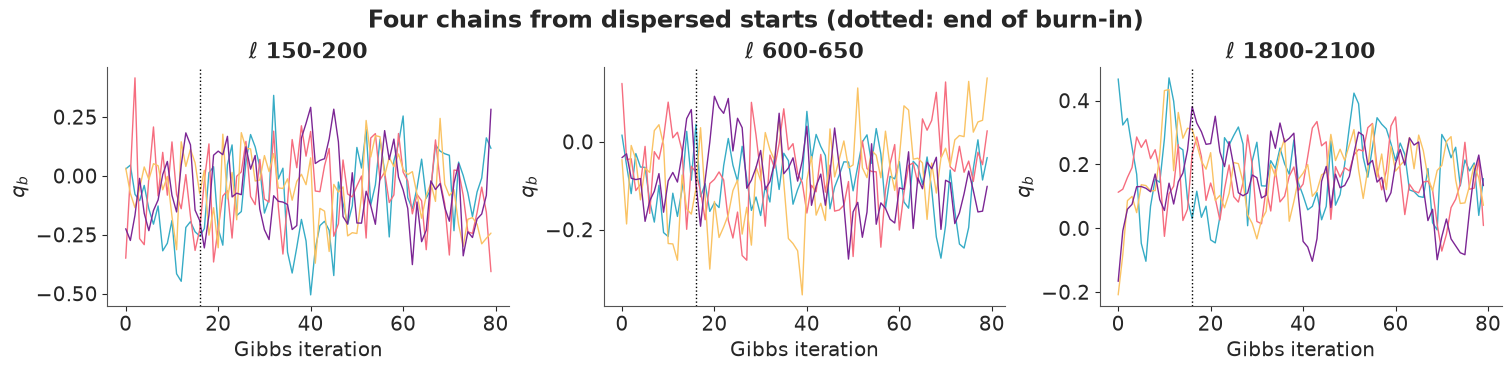

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6), layout="constrained")
for ax, b in zip(axs, [3, 12, NB - 1]):
    for c in range(4):
        ax.plot(res["q"][:, c, b], lw=1)
    ax.axvline(res["burn"], color="k", ls=":", lw=1)
    ax.set(title=fr"$\ell$ {EDGES[b]}-{EDGES[b + 1]}", xlabel="Gibbs iteration", ylabel="$q_b$")
fig.suptitle("Four chains from dispersed starts (dotted: end of burn-in)");

The chains start from different spectra and forget them within a few iterations - at high
signal-to-noise each Gibbs step is close to an independent draw. The table says the same: r_hat is
at most 1.11 and bulk ESS runs from 28 to about 200 out of 256 draws - enough for bandpowers, and it
costs half a minute. The rescaling move is almost always rejected in the large-scale bins, where
the data pin the sky and it cannot help, and accepted about half of the time in the
noise-dominated top bins, where the centred Gibbs step alone mixes slowly.

## F. What is behind the LMC?

### The posterior sky

The **posterior mean** of the sky is the Wiener-filtered map (averaged over the spectrum's
uncertainty); each Gibbs iteration also gave a complete sky drawn from the posterior - a
**constrained realisation**. The maps below are the sky as Planck would see it (with the 5' beam).

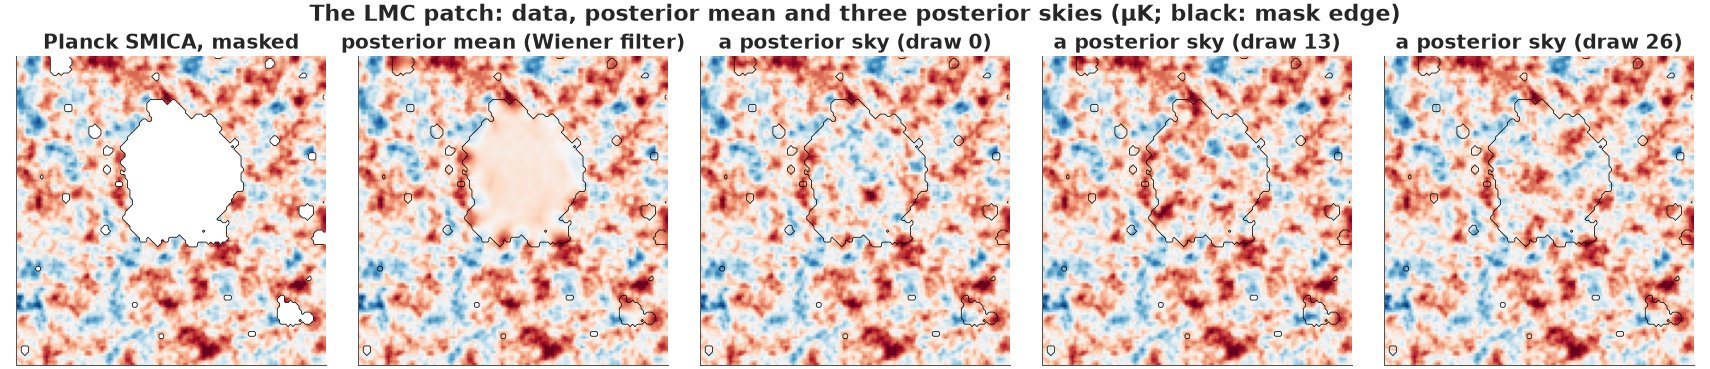

In [13]:
pad = gibbs.pad
cut = (slice(None), slice(pad, pad + N_OBS), slice(pad, pad + N_OBS))
post_mean = res["mean"][cut].mean(0)
post_sd = np.sqrt(np.maximum(res["sq"][cut].mean(0) - post_mean**2, 0))
draws = res["maps"][:, 0]                                    # chain 0, the last 40 iterations
fig, axs = plt.subplots(1, 5, figsize=(19, 4.1), layout="constrained")
axs[0].imshow(np.where(obs_lmc, y_lmc, np.nan), **kw)
axs[0].set_title("Planck SMICA, masked")
axs[1].imshow(post_mean, **kw)
axs[1].set_title("posterior mean (Wiener filter)")
for ax, d in zip(axs[2:], [0, 13, 26]):
    ax.imshow(draws[d], **kw)
    ax.set_title(f"a posterior sky (draw {d})")
for ax in axs:
    ax.contour(obs_lmc, levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=ext)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("The LMC patch: data, posterior mean and three posterior skies (μK; black: mask edge)")
show_jpeg(fig)

Outside the mask all five maps agree to the eye: the data are so precise there that every
posterior sky reproduces them. Inside the LMC hole they differ. The posterior mean continues the
structures that cross the edge of the hole for a fraction of a degree and then fades to an almost
featureless level near the patch's mean temperature; each posterior sky continues the same structures *and* fills the middle with CMB of the
right statistics, and each fills it differently. The mean is the best single guess, but it is not
a plausible sky (too smooth, too little power in the hole); the draws are plausible skies, but
none of them is "the" answer. The animation cycles through forty of them: what stands still is
known, what flickers is not.

In [14]:
fig, ax = plt.subplots(figsize=(4.6, 4.3), dpi=72, layout="constrained")
frame = ax.imshow(draws[0], **kw)
ax.contour(obs_lmc, levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=ext)
ax.set_xticks([])
ax.set_yticks([])


def update(k):
    frame.set_data(draws[k])
    ax.set_title(f"posterior sky {k + 1} of {len(draws)}", fontsize=9)
    return (frame,)


anim = animation.FuncAnimation(fig, update, frames=range(len(draws)), interval=350)
plt.close(fig)
plt.rcParams["animation.frame_format"] = "jpeg"
display(HTML(anim.to_jshtml(default_mode="loop")))
plt.rcParams["animation.frame_format"] = "png"

### How uncertain, where?

The per-pixel posterior sd, and a close-up of the hole with Planck's own inpainted map for
comparison. (SMICA's inpainted map is released "for PR purposes": one plausible fill, not an
analysis product.)

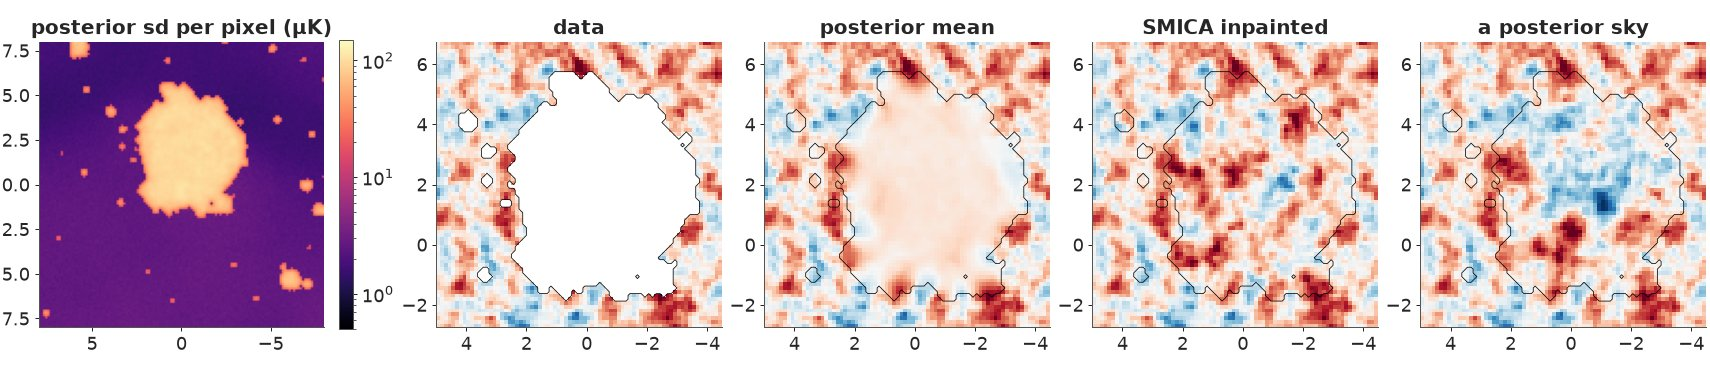

posterior sd (median): 2.5 uK in observed pixels, 32 uK in the small holes, 92 uK in the LMC hole (max 110); prior sd of a pixel 98 uK
posterior mean inside the LMC hole: 38 +- 43 uK (pixel mean and spread); observed pixels: mean 43 uK
SMICA's inpainting inside the mask, in posterior sds from our mean: |z| < 1 for 67% of pixels, |z| < 2 for 94%


In [15]:
hole = ~obs_lmc
lab, _ = ndimage.label(hole)
big_hole = lab == np.bincount(lab.ravel())[1:].argmax() + 1      # the LMC; the rest are small holes
z_inp = (inp_lmc - post_mean) / post_sd
fig, axs = plt.subplots(1, 5, figsize=(19, 4.1), layout="constrained")
im = axs[0].imshow(post_sd, origin="lower", extent=ext, cmap="magma", norm=LogNorm(0.5, 150))
axs[0].set_title("posterior sd per pixel (μK)")
fig.colorbar(im, ax=axs[0], shrink=0.8)
r0, r1, c0, c1 = 42, 118, 24, 100                             # rows (b) and columns (l) around the hole
zoom = (slice(r0, r1), slice(c0, c1))
px = 7.5 / 60
zext = [ext[0] - c0 * px, ext[0] - c1 * px, ext[2] + r0 * px, ext[2] + r1 * px]
for ax, img, title in [(axs[1], np.where(obs_lmc, y_lmc, np.nan), "data"),
                       (axs[2], post_mean, "posterior mean"), (axs[3], inp_lmc, "SMICA inpainted"),
                       (axs[4], draws[5], "a posterior sky")]:
    ax.imshow(img[zoom], origin="lower", extent=zext, cmap="RdBu_r", vmin=-300, vmax=300)
    ax.contour(obs_lmc[zoom], levels=[0.5], colors="k", linewidths=0.6, origin="lower", extent=zext)
    ax.set_title(title)
show_jpeg(fig)
print(f"posterior sd (median): {np.median(post_sd[obs_lmc]):.1f} uK in observed pixels, "
      f"{np.median(post_sd[hole & ~big_hole]):.0f} uK in the small holes, {np.median(post_sd[big_hole]):.0f} uK "
      f"in the LMC hole (max {post_sd.max():.0f}); prior sd of a pixel {np.sqrt(gibbs.S0.sum() - gibbs.S0[0, 0]):.0f} uK")
print(f"posterior mean inside the LMC hole: {post_mean[big_hole].mean():.0f} +- {post_mean[big_hole].std():.0f} uK "
      f"(pixel mean and spread); observed pixels: mean {y_lmc[obs_lmc].mean():.0f} uK")
print(f"SMICA's inpainting inside the mask, in posterior sds from our mean: |z| < 1 for "
      f"{np.mean(np.abs(z_inp[hole]) < 1):.0%} of pixels, |z| < 2 for {np.mean(np.abs(z_inp[hole]) < 2):.0%}")

In observed pixels the posterior sd is at the noise level (2.5 μK). In the LMC hole it is 92 μK,
essentially the prior sd of a pixel: a degree or two from the nearest data the map knows almost
nothing, and only a thin rim along the edge is constrained. The small holes around point sources
sit in between, at about 32 μK: their surroundings fix the degree-scale spots that pass through
them, but not the arcminute structure inside. And SMICA's inpainted map is within one of our
posterior sds of the posterior mean in 67% of the hole's pixels and within two in 94% - just what
a single draw from our posterior would do (68% and 95%). Its fill is one of the skies our model
considers plausible, not a measurement of what is there.

### Bandpowers

And the spectrum itself - the field-level posterior for each bandpower, against the Planck best
fit, Planck's full-sky measurement and the naive estimate of Part C.

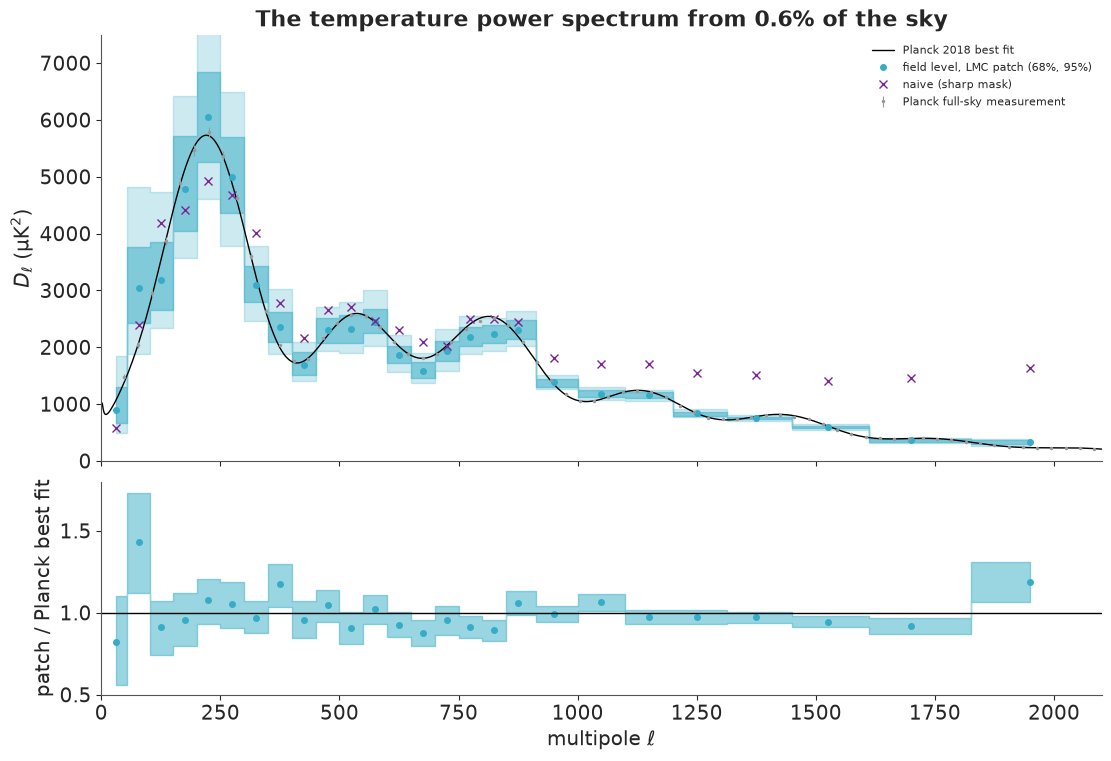

In [16]:
Dpost = np.exp(post_q.reshape(-1, NB)) * DL_PLANCK_B
fig, axs = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True, layout="constrained",
                        gridspec_kw={"height_ratios": [2, 1]})
ax = axs[0]
ax.plot(ell, dl(ell, cl_planck(ell)), "k", lw=1, label="Planck 2018 best fit")
ax.errorbar(binned.ell, binned.Dl, yerr=binned.dDl_hi, fmt=".", color="0.6", ms=3, lw=0.8,
            label="Planck full-sky measurement")
for lo, hi, a in [(0.025, 0.975, 0.25), (0.16, 0.84, 0.5)]:
    ax.fill_between(ELL_B, np.quantile(Dpost, lo, 0), np.quantile(Dpost, hi, 0), step="mid", color="C0", alpha=a)
ax.plot(ELL_B, np.median(Dpost, 0), "o", color="C0", ms=4, label="field level, LMC patch (68%, 95%)")
ax.plot(ELL_B, naive_real, "x", color="C3", label="naive (sharp mask)")
ax.set(ylim=(0, 7500), ylabel=r"$D_\ell$ (μK$^2$)", title="The temperature power spectrum from 0.6% of the sky")
ax.legend(fontsize=8)
ax = axs[1]
ax.fill_between(ELL_B, np.quantile(np.exp(post_q.reshape(-1, NB)), 0.16, 0),
                np.quantile(np.exp(post_q.reshape(-1, NB)), 0.84, 0), step="mid", color="C0", alpha=0.5)
ax.plot(ELL_B, np.exp(post_q.reshape(-1, NB)).mean(0), "o", color="C0", ms=4)
ax.axhline(1, color="k", lw=1)
ax.set(ylim=(0.5, 1.8), xlabel=r"multipole $\ell$", ylabel="patch / Planck best fit", xlim=(0, 2100));

The field-level bandpowers trace the acoustic peaks from $\ell \approx 60$ to 2000 with
uncertainties that are honest for a patch this small: tens of per cent at the largest scales,
where a 16° patch holds only a handful of independent modes (**cosmic variance**), a few per cent at
the smallest. The naive estimate, run on the same data, departs from them at high $\ell$ exactly as
the simulations predicted.

The ratio panel shows the patch agreeing with the Planck best fit: the bins scatter around 1 and
none is more than about 1.6 posterior sds away (the largest departures are the bin at
$\ell \approx 80$, 40% high with a 25% uncertainty, and the top bin, 18% high). That is what one
patch of a ΛCDM sky should look like - but it is only convincing if the method would have found a
*different* spectrum had there been one. Part G checks that.

## G. Can we trust it? Simulated skies with a known truth

Eight simulated skies, made the way the data were made (fine sampling, beam, 8 x 8 averaging, a
non-periodic cut) with the LMC mask and the LMC noise map, and - so that the answer is not the
model's own reference spectrum - a **different spectrum**: 15% more power than Planck and a tilt of
$-0.1$ in $\ell$. One Gibbs chain per sky, all eight run together.

In [17]:
def truth_scale(ell):
    return 1.15 * (np.maximum(ell, 1) / 500) ** -0.1


q_truth = np.log([np.sum((gibbs.S0 * truth_scale(gibbs.ell))[gibbs.bin == b]) / np.sum(gibbs.S0[gibbs.bin == b])
                  for b in range(NB)])
n_sim = 8
r_sim = np.random.default_rng(2024)
y_sims = np.array([simulate_sky(np.random.default_rng(3000 + i), cl_scale=truth_scale)[0]
                   + sigma_lmc * r_sim.standard_normal(sigma_lmc.shape) for i in range(n_sim)])
t0 = time.time()
res_sim = gibbs.run(y_sims, 50, r_sim, q0=np.zeros((n_sim, NB)))
print(f"{n_sim} skies x 50 iterations in {time.time() - t0:.0f} s")
qs = res_sim["q"][res_sim["burn"]:]                          # (draw, sim, bin)
pit = (qs < q_truth).mean(0)                                 # posterior probability below the truth
zsc = (q_truth - qs.mean(0)) / qs.std(0)
inside90 = (pit > 0.05) & (pit < 0.95)
inside50 = (pit > 0.25) & (pit < 0.75)
print(f"truth inside the central 90% interval: {inside90.mean():.0%} of {inside90.size} (sky, bin) pairs; "
      f"inside the 50% interval: {inside50.mean():.0%}")
print(f"z = (truth - posterior mean) / posterior sd: mean {zsc.mean():+.2f}, sd {zsc.std():.2f}")

8 skies x 50 iterations in 44 s
truth inside the central 90% interval: 83% of 208 (sky, bin) pairs; inside the 50% interval: 48%
z = (truth - posterior mean) / posterior sd: mean +0.03, sd 1.09


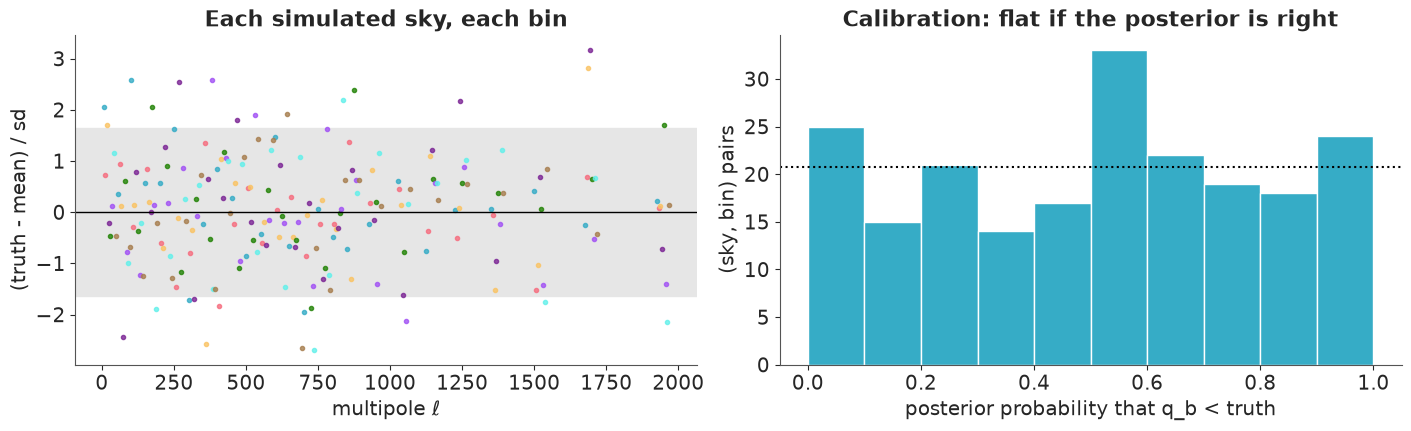

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2), layout="constrained")
ax = axs[0]
for i in range(n_sim):
    ax.plot(ELL_B + (i - n_sim / 2) * 6, zsc[i], "o", ms=3, alpha=0.8)
ax.axhspan(-1.645, 1.645, color="0.9")
ax.axhline(0, color="k", lw=1)
ax.set(xlabel=r"multipole $\ell$", ylabel="(truth - mean) / sd", title="Each simulated sky, each bin")
ax = axs[1]
ax.hist(pit.ravel(), bins=np.linspace(0, 1, 11), color="C0", edgecolor="w")
ax.axhline(pit.size / 10, color="k", ls=":")
ax.set(xlabel="posterior probability that q_b < truth", ylabel="(sky, bin) pairs",
       title="Calibration: flat if the posterior is right");

The posterior is close to calibrated. The standardised errors average +0.03 with a spread of 1.09
and show no trend with $\ell$; the truth is inside the central 50% interval for 48% of the (sky,
bin) pairs and inside the 90% interval for 83%, and the histogram of posterior probabilities is
flat within its noise. The small shortfall at 90% is partly Monte Carlo noise (only 40 draws per
sky, so each tail probability is itself uncertain) and possibly a slightly overconfident posterior;
more skies and longer chains would tell the two apart. The method recovers a spectrum 15% above
Planck's, tilted, without trouble.

Getting here needed every detail of Parts B and E. While building this notebook, simulations like
these showed that without the border the seam of a periodic model made fake small-scale power;
without folding in aliased power the top bins came out high; and with CG stopped at a looser
tolerance and no dense preconditioner, the unconverged directions inside the hole made the
large-scale bins come out 30-40% low.

## H. From bandpowers to parameters

Cosmological parameters enter through $C_\ell$, so the last step in a real analysis would feed the
bandpower posterior to a Boltzmann code. We stop at a two-parameter caricature that keeps the
logic: the patch's spectrum is Planck's times an **amplitude** $A$ and a **tilt** $n$,
$C_\ell = A\,(\ell/500)^{n}\,C_\ell^{\text{Planck}}$. The field-level posterior of the bandpowers,
summarised by the mean and variance of each $q_b$ over the Gibbs draws (neighbouring bins are nearly
independent), becomes a Gaussian likelihood
for $(\log A, n)$ in a small PyMC model. We leave out the three top bins, where the aliasing
correction matters most.

In [19]:
def amp_tilt(q_draws, sel, label):
    qm = q_draws.reshape(-1, NB)[:, sel].mean(0)
    cov = np.diag(q_draws.reshape(-1, NB)[:, sel].var(0))     # bins are nearly independent
    with pm.Model(coords={"bin": ELL_B[sel]}) as m:
        logA = pm.Normal("logA", 0, 0.5)
        tilt = pm.Normal("tilt", 0, 0.5)
        mu = logA + tilt * np.log(ELL_B[sel] / 500)
        pm.MvNormal("q_hat", mu=mu, cov=cov, observed=qm, dims="bin")
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    s = az.summary(idata, var_names=["logA", "tilt"], round_to=3)
    s.insert(0, "bins", label)
    return idata, s


sel = ELL_B < 1450
t0 = time.time()
res_flat = FieldSampler(obs_lmc, sigma_lmc, stretch=1.0).run(y_lmc, 60, np.random.default_rng(7), q0=np.zeros((4, NB)))
print(f"Gibbs run without the projection correction: {time.time() - t0:.0f} s")
out_h = [amp_tilt(post_q, sel, "real sky"),
         amp_tilt(res_flat["q"][res_flat["burn"]:], sel, "real sky, no projection correction")]
sim_rows = []
for i in range(n_sim):
    idata_i, s_i = amp_tilt(qs[:, i][:, None], sel, f"simulated sky {i + 1}")
    if i == 0:
        out_h.append((idata_i, s_i))
    for v, truth in [("logA", np.log(1.15)), ("tilt", -0.1)]:
        lo, hi = np.quantile(idata_i.posterior[v].values, [0.05, 0.95])
        sim_rows.append({"sky": i + 1, "parameter": v, "mean": idata_i.posterior[v].values.mean(), "5%": lo,
                         "95%": hi, "truth inside": lo < truth < hi})
print(pd.concat([o[1] for o in out_h]).to_string())
sim_tab = pd.DataFrame(sim_rows)
print(sim_tab.round(3).to_string(index=False))
print(sim_tab.groupby("parameter")["truth inside"].mean())

Gibbs run without the projection correction: 21 s


                                    bins   mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
logA                            real sky -0.014  0.023    -0.050     0.021  1147.289  1548.852  1.003      0.001    0.000
tilt                            real sky -0.009  0.030    -0.056     0.038  1101.251  1615.218  1.001      0.001    0.001
logA  real sky, no projection correction -0.028  0.020    -0.061     0.005  1688.320  2026.882  1.000      0.000    0.000
tilt  real sky, no projection correction -0.017  0.027    -0.061     0.026  1509.099  1891.308  1.000      0.001    0.000
logA                     simulated sky 1  0.115  0.021     0.081     0.149  1389.321  1746.693  1.001      0.001    0.000
tilt                     simulated sky 1 -0.048  0.029    -0.092    -0.000  1413.076  1707.774  1.000      0.001    0.000
 sky parameter   mean     5%    95%  truth inside
   1      logA  0.115  0.080  0.150          True
   1      tilt -0.048 -0.093  0.001         Fa

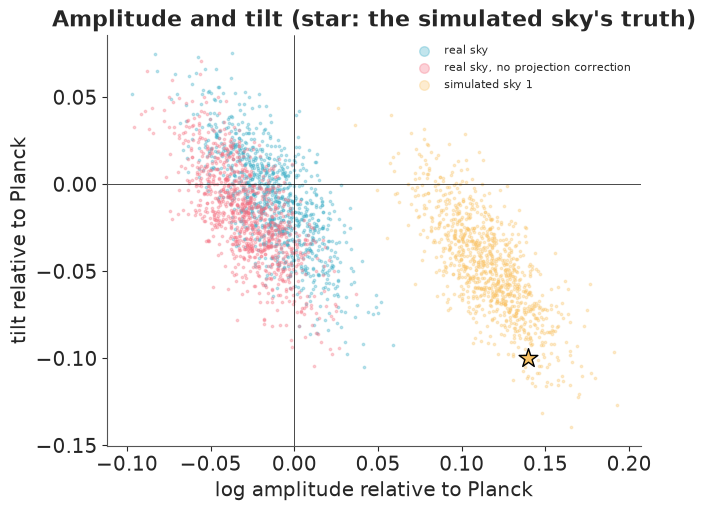

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for (idata, s), c in zip(out_h, ["C0", "C1", "C2"]):
    ax.scatter(idata.posterior["logA"].values.ravel()[::4], idata.posterior["tilt"].values.ravel()[::4], s=3,
               alpha=0.3, color=c, label=s["bins"].iloc[0])
ax.scatter([np.log(1.15)], [-0.1], marker="*", s=200, color="C2", edgecolor="k", zorder=3)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set(xlabel="log amplitude relative to Planck", ylabel="tilt relative to Planck",
       title="Amplitude and tilt (star: the simulated sky's truth)")
ax.legend(fontsize=8, markerscale=4);

On the eight simulated skies the two-parameter summary finds what it was given: the 90% intervals
contain the true amplitude for all eight and the true tilt for seven (sky 1, shown, is the
exception, 1.8 sds from its truth). On the real LMC patch the amplitude is within 1.4% of Planck's
(-0.014 ± 0.023 in log) and the tilt is -0.009 ± 0.030: no departure from the Planck spectrum at
all, at the precision one 16° patch allows.

The second real-sky fit asks how much one of our instrument-model details matters: the same
analysis without the correction for the projection's stretch. It moves the amplitude by 1.4%
(about 0.6 sd) and the tilt by less than 0.3 sd. Small here - but a patch 0.6% of the sky has
large error bars, and the same 1-2% shift would be many sds on the full sky. That is the general
lesson: a systematic is small or large only *relative to the statistical error*, and the error
shrinks with more data while the systematic does not. Our other instrument assumptions (SMICA's
beam exactly a 5' Gaussian, the pixel windows as the whole transfer function, a uniform stretch
where the real one varies from 1.00 at the centre to about 1.03 in the corners) are of the same
order and would need the same treatment in a real analysis: as parameters with priors.

The time for the whole notebook:

In [21]:
print(f"total run time {time.time() - T_START:.0f} s")

total run time 150 s


## Summary

* **The CMB is a Gaussian random field**, so its power spectrum is a sufficient statistic - *for
  a complete map with uniform noise*. With no mask, the field-level posterior for the bandpowers
  reproduced the exact power-spectrum posterior. Real maps have holes, uneven noise and edges, and
  then the obvious power-spectrum estimate is biased by large factors (leakage from sharp edges),
  while a model of the map needs no corrections: masked pixels just have no likelihood.
* **Field-level inference means sampling the sky.** Tens of thousands of parameters are fine when
  the posterior is well conditioned. The centred vs non-centred choice appeared in its textbook
  form, with zero divergences: non-centred freezes where the data are strong, centred where they
  are weak, and partial non-centring by each mode's signal-to-noise works for both.
* **A mask makes the problem ill-conditioned**, and HMC with a diagonal mass matrix hits maximum
  tree depth on every draw. The Wandelt-Eriksen Gibbs sampler - constrained realisations by
  preconditioned conjugate gradients, an inverse-gamma step for the spectrum, and a non-centred
  rescaling move - handles the real 144 x 144 torus (20,736 sky parameters) in half a minute.
* **The posterior products are skies.** The posterior mean is the Wiener filter; posterior draws
  are constrained realisations that fill the LMC hole with plausible CMB, different each time; the
  sd map says where the data stop. Planck's own inpainting is one such plausible sky.
* **Simulations with a known, non-Planck truth are the test that matters.** They caught three
  flat-sky traps (a periodic seam, aliasing, under-converged CG) before the data did; after the
  fixes the bandpower posteriors were close to calibrated and a two-parameter summary recovered a
  non-Planck truth. The real LMC patch agrees with Planck's spectrum. What simulations cannot
  catch is a wrong model of the instrument: those assumptions belong in the model, with priors.

## Try it yourself

1. **Polarisation.** The SMICA files also contain Q and U maps. Add them to the build script and
   extend the field to three components (T, E, B) with a 3 x 3 spectrum per mode (TT, TE, EE; BB
   zero or free). The inverse-gamma step becomes an inverse-Wishart. How well does a 16° patch
   constrain the TE cross-spectrum, and how noisy is Planck's polarisation compared with its
   temperature?
2. **Lensing.** Gravitational lensing by large-scale structure remaps the CMB by a few arcminutes:
   $T(\mathbf x) = \tilde T(\mathbf x + \nabla\phi)$. On a simulated patch, make $\phi$ a second
   Gaussian field and write the remapping with interpolation; can a field-level model recover the
   lensing potential's amplitude? (This is how modern lensing analyses such as Millea et al.'s work;
   at Planck's noise the signal on one patch is small - try a lower-noise simulation.)
3. **Cosmological parameters.** Replace amplitude and tilt with a physical spectrum: the E08
   distance machinery plus a simple model of the acoustic peaks (e.g. the peak spacing set by the
   sound horizon over the angular distance), or tabulated spectra from a Boltzmann code for a grid
   of parameters, interpolated inside PyMC. Then add the beam FWHM as a nuisance parameter with a
   prior of a few per cent: how much wider do the amplitude and tilt posteriors get?